In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. DEFINE THE BASKET
pairs = [
    "EURUSD=X", "USDJPY=X", "GBPUSD=X", "AUDUSD=X", 
    "USDCAD=X", "USDCHF=X", "NZDUSD=X", "EURJPY=X", 
    "GBPJPY=X", "EURGBP=X"
]

def calculate_indicators(df):
    # --- A. TREND FILTER (ADX) ---
    df['H-L'] = df['High'] - df['Low']
    df['H-C'] = abs(df['High'] - df['Close'].shift(1))
    df['L-C'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-C', 'L-C']].max(axis=1)
    
    df['UpMove'] = df['High'] - df['High'].shift(1)
    df['DownMove'] = df['Low'].shift(1) - df['Low']
    
    df['+DM'] = np.where((df['UpMove'] > df['DownMove']) & (df['UpMove'] > 0), df['UpMove'], 0)
    df['-DM'] = np.where((df['DownMove'] > df['UpMove']) & (df['DownMove'] > 0), df['DownMove'], 0)
    
    window = 14
    df['TR14'] = df['TR'].rolling(window).sum()
    df['+DM14'] = df['+DM'].rolling(window).sum()
    df['-DM14'] = df['-DM'].rolling(window).sum()
    
    df['+DI'] = 100 * (df['+DM14'] / df['TR14'])
    df['-DI'] = 100 * (df['-DM14'] / df['TR14'])
    
    # Handle division by zero if TR14 is 0
    df['DX'] = 0.0
    mask = (df['+DI'] + df['-DI']) > 0
    df.loc[mask, 'DX'] = 100 * abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])
    
    df['ADX'] = df['DX'].rolling(window).mean()
    
    # --- B. VOLATILITY FILTER (Normalized ATR) ---
    df['ATR'] = df['TR'].rolling(14).mean()
    df['Norm_ATR'] = (df['ATR'] / df['Close']) * 100 
    
    # --- C. BREAKOUT SIGNALS ---
    df['20_Day_High'] = df['High'].rolling(20).max().shift(1)
    df['20_Day_Low'] = df['Low'].rolling(20).min().shift(1)
    
    return df.iloc[-1]

# 2. RUN SCREENER
print(f"{'PAIR':<10} {'ADX (Trend)':<12} {'VOL %':<10} {'PRICE':<10} {'SIGNAL'}")
print("-" * 65)

for ticker in pairs:
    try:
        # FIX: Added auto_adjust=False to silence warning
        df = yf.download(ticker, period="6mo", interval="1d", progress=False, auto_adjust=False)
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
            
        latest = calculate_indicators(df)
        
        adx = latest['ADX']
        vol = latest['Norm_ATR']
        price = latest['Close']
        high_20 = latest['20_Day_High']
        low_20 = latest['20_Day_Low']
        
        signal = "WAIT"
        
        if adx > 20 and vol > 0.3:
            if price > high_20:
                signal = "BUY BREAKOUT"
            elif price < low_20:
                signal = "SELL BREAKOUT"
            else:
                signal = "IN RANGE"
        else:
            signal = "IGNORE (Flat)"
            
        print(f"{ticker:<10} {adx:<12.2f} {vol:<10.2f} {price:<10.4f} {signal}")
        
    except Exception as e:
        print(f"Error with {ticker}: {e}")

PAIR       ADX (Trend)  VOL %      PRICE      SIGNAL
-----------------------------------------------------------------
EURUSD=X   10.22        0.49       1.1612     IGNORE (Flat)
USDJPY=X   32.70        0.72       155.9740   IN RANGE
GBPUSD=X   20.84        0.59       1.3197     IN RANGE
AUDUSD=X   15.77        0.71       0.6550     IGNORE (Flat)
USDCAD=X   14.68        0.43       1.4011     IGNORE (Flat)
USDCHF=X   7.73         0.72       0.8046     IGNORE (Flat)
NZDUSD=X   35.38        0.82       0.5717     IN RANGE
EURJPY=X   35.10        0.60       181.0720   IN RANGE
GBPJPY=X   35.63        0.68       205.8560   IN RANGE
EURGBP=X   22.41        0.44       0.8796     IN RANGE


--- GBPJPY=X ---
Total Return: -4.10%
Max Drawdown: -15.93%
--- EURJPY=X ---
Total Return: -14.50%
Max Drawdown: -18.20%
--- NZDUSD=X ---
Total Return: -1.90%
Max Drawdown: -12.90%
--- USDJPY=X ---
Total Return: 22.62%
Max Drawdown: -9.53%


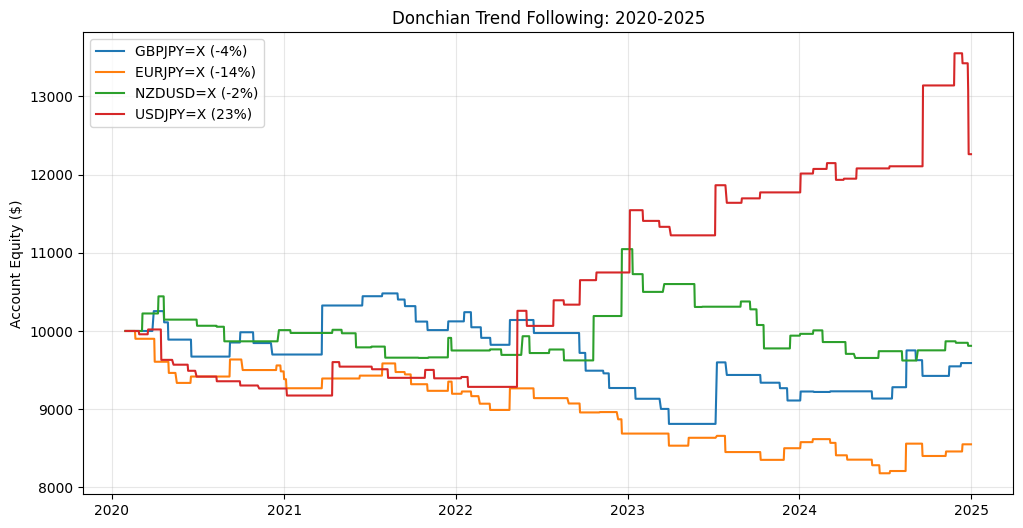

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'EURJPY=X', 'NZDUSD=X', 'USDJPY=X']
START_DATE = "2020-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 

def calculate_adx(df, period=14):
    df = df.copy()
    df['H-L'] = df['High'] - df['Low']
    df['H-C'] = abs(df['High'] - df['Close'].shift(1))
    df['L-C'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-C', 'L-C']].max(axis=1)
    
    df['UpMove'] = df['High'] - df['High'].shift(1)
    df['DownMove'] = df['Low'].shift(1) - df['Low']
    df['+DM'] = np.where((df['UpMove'] > df['DownMove']) & (df['UpMove'] > 0), df['UpMove'], 0)
    df['-DM'] = np.where((df['DownMove'] > df['UpMove']) & (df['DownMove'] > 0), df['DownMove'], 0)
    
    df['TR14'] = df['TR'].rolling(period).sum()
    df['+DM14'] = df['+DM'].rolling(period).sum()
    df['-DM14'] = df['-DM'].rolling(period).sum()
    
    df['+DI'] = 100 * (df['+DM14'] / df['TR14'])
    df['-DI'] = 100 * (df['-DM14'] / df['TR14'])
    
    # Fix division by zero
    df['DX'] = 0.0
    mask = (df['+DI'] + df['-DI']) > 0
    df.loc[mask, 'DX'] = 100 * abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])
    
    df['ADX'] = df['DX'].rolling(period).mean()
    return df['ADX']

def backtest_pair(ticker):
    # 1. Get Data
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # 2. Indicators
    df['ADX'] = calculate_adx(df)
    
    df['20_High'] = df['High'].rolling(20).max().shift(1)
    df['20_Low'] = df['Low'].rolling(20).min().shift(1)
    df['10_High'] = df['High'].rolling(10).max().shift(1)
    df['10_Low'] = df['Low'].rolling(10).min().shift(1)
    
    # 3. Iterative Backtest
    position = 0 
    entry_price = 0.0
    
    # FIX: Initialize empty list, append daily
    equity = [] 
    
    # Convert to Numpy
    closes = df['Close'].values
    highs = df['High'].values
    lows = df['Low'].values
    adx = df['ADX'].values
    h20 = df['20_High'].values
    l20 = df['20_Low'].values
    h10 = df['10_High'].values
    l10 = df['10_Low'].values
    
    # FIX: Align dates with the loop
    dates = df.index[21:] 
    
    current_equity = INITIAL_CAPITAL
    
    # Loop starts at 21
    for i in range(21, len(df)):
        
        # --- EXIT LOGIC ---
        if position == 1:
            if lows[i] < l10[i]: # Hit trailing stop
                exit_price = l10[i]
                pnl = (exit_price - entry_price) - PIP_COST
                pct_pnl = pnl / entry_price
                current_equity = current_equity * (1 + pct_pnl)
                position = 0
                
        elif position == -1:
            if highs[i] > h10[i]: # Hit trailing stop
                exit_price = h10[i]
                pnl = (entry_price - exit_price) - PIP_COST
                pct_pnl = pnl / entry_price
                current_equity = current_equity * (1 + pct_pnl)
                position = 0

        # --- ENTRY LOGIC ---
        if position == 0:
            if adx[i] > 25:
                if highs[i] > h20[i]: # Long Breakout
                    entry_price = h20[i]
                    position = 1
                elif lows[i] < l20[i]: # Short Breakout
                    entry_price = l20[i]
                    position = -1
        
        # FIX: Append equity at the end of every day
        equity.append(current_equity)
            
    # Calculate Stats
    total_ret = (current_equity - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    
    # Max Drawdown
    max_dd = 0
    if len(equity) > 0:
        eq_series = pd.Series(equity)
        dd = (eq_series - eq_series.cummax()) / eq_series.cummax()
        max_dd = dd.min() * 100
    
    return total_ret, max_dd, equity, dates

# 4. RUN PLOT
plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        ret, dd, eq_curve, dates = backtest_pair(pair)
        print(f"--- {pair} ---")
        print(f"Total Return: {ret:.2f}%")
        print(f"Max Drawdown: {dd:.2f}%")
        
        plt.plot(dates, eq_curve, label=f"{pair} ({ret:.0f}%)")
        
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("Donchian Trend Following: 2020-2025")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- GBPJPY=X ---
Total Return: -4.46%
Max Drawdown: -8.36%
--- EURJPY=X ---
Total Return: -0.24%
Max Drawdown: -6.30%
--- NZDUSD=X ---
Total Return: 5.72%
Max Drawdown: -11.40%
--- USDJPY=X ---
Total Return: -11.99%
Max Drawdown: -15.72%


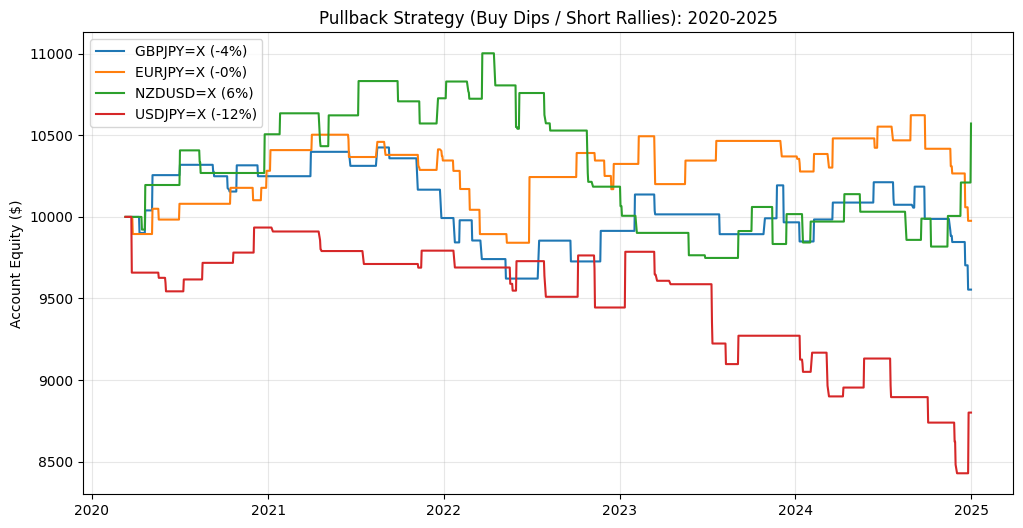

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'EURJPY=X', 'NZDUSD=X', 'USDJPY=X']
START_DATE = "2020-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 

def calculate_adx(df, period=14):
    df = df.copy()
    df['H-L'] = df['High'] - df['Low']
    df['H-C'] = abs(df['High'] - df['Close'].shift(1))
    df['L-C'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-C', 'L-C']].max(axis=1)
    
    df['UpMove'] = df['High'] - df['High'].shift(1)
    df['DownMove'] = df['Low'].shift(1) - df['Low']
    df['+DM'] = np.where((df['UpMove'] > df['DownMove']) & (df['UpMove'] > 0), df['UpMove'], 0)
    df['-DM'] = np.where((df['DownMove'] > df['UpMove']) & (df['DownMove'] > 0), df['DownMove'], 0)
    
    df['TR14'] = df['TR'].rolling(period).sum()
    df['+DM14'] = df['+DM'].rolling(period).sum()
    df['-DM14'] = df['-DM'].rolling(period).sum()
    df['+DI'] = 100 * (df['+DM14'] / df['TR14'])
    df['-DI'] = 100 * (df['-DM14'] / df['TR14'])
    
    # Fix division by zero
    df['DX'] = 0.0
    mask = (df['+DI'] + df['-DI']) > 0
    df.loc[mask, 'DX'] = 100 * abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])
    
    df['ADX'] = df['DX'].rolling(period).mean()
    return df['ADX']

def backtest_pullback(ticker):
    # 1. Get Data
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # 2. Indicators
    df['ADX'] = calculate_adx(df)
    df['SMA_50'] = df['Close'].rolling(50).mean() # Trend Filter
    
    # Donchian Channels
    df['20_Low'] = df['Low'].rolling(20).min().shift(1) # Major Support (Stop Loss)
    df['20_High'] = df['High'].rolling(20).max().shift(1) # Major Resistance (Stop Loss for Short)
    
    df['10_Low'] = df['Low'].rolling(10).min().shift(1) # Buy Trigger (Dip)
    df['10_High'] = df['High'].rolling(10).max().shift(1) # Sell Trigger (Rally)
    
    # 3. Iterative Backtest
    position = 0 
    entry_price = 0.0
    equity = [] 
    dates = df.index[50:] 
    
    # Convert to Numpy
    closes = df['Close'].values
    highs = df['High'].values
    lows = df['Low'].values
    adx = df['ADX'].values
    sma50 = df['SMA_50'].values
    
    l20 = df['20_Low'].values
    h20 = df['20_High'].values
    l10 = df['10_Low'].values
    h10 = df['10_High'].values
    
    current_equity = INITIAL_CAPITAL
    
    # Loop starts at 50 (for SMA)
    for i in range(50, len(df)):
        
        # --- EXIT LOGIC ---
        if position == 1:
            # Profit Take: We hit the 10-day High (Snap back complete)
            if highs[i] > h10[i]:
                exit_price = h10[i]
                pnl = (exit_price - entry_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
            # Stop Loss: We broke the 20-day Low (Trend Failed)
            elif lows[i] < l20[i]:
                exit_price = l20[i]
                pnl = (exit_price - entry_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                
        elif position == -1:
            # Profit Take: We hit the 10-day Low
            if lows[i] < l10[i]:
                exit_price = l10[i]
                pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
            # Stop Loss: We broke the 20-day High
            elif highs[i] > h20[i]:
                exit_price = h20[i]
                pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0

        # --- ENTRY LOGIC ---
        if position == 0 and adx[i] > 25:
            
            # LONG SETUP: Uptrend (Price > SMA50) but Dip (Price < 10-Day Low)
            if closes[i] > sma50[i]:
                if lows[i] < l10[i]:
                    entry_price = l10[i] # Buy the dip limit
                    position = 1
                    
            # SHORT SETUP: Downtrend (Price < SMA50) but Rally (Price > 10-Day High)
            elif closes[i] < sma50[i]:
                if highs[i] > h10[i]:
                    entry_price = h10[i] # Short the spike limit
                    position = -1
        
        equity.append(current_equity)
            
    # Stats
    total_ret = (current_equity - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    max_dd = 0
    if len(equity) > 0:
        eq_series = pd.Series(equity)
        dd = (eq_series - eq_series.cummax()) / eq_series.cummax()
        max_dd = dd.min() * 100
    
    return total_ret, max_dd, equity, dates

# 4. RUN PLOT
plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        ret, dd, eq_curve, dates = backtest_pullback(pair)
        print(f"--- {pair} ---")
        print(f"Total Return: {ret:.2f}%")
        print(f"Max Drawdown: {dd:.2f}%")
        
        plt.plot(dates, eq_curve, label=f"{pair} ({ret:.0f}%)")
        
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("Pullback Strategy (Buy Dips / Short Rallies): 2020-2025")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- GBPJPY=X ---
Total Return: 73.31%
Max Drawdown: -26.17%
--- EURJPY=X ---
Total Return: -3.95%
Max Drawdown: -25.55%
--- NZDUSD=X ---
Total Return: -41.53%
Max Drawdown: -52.33%
--- USDJPY=X ---
Total Return: 2.66%
Max Drawdown: -29.72%
--- EURUSD=X ---
Total Return: -5.28%
Max Drawdown: -23.38%


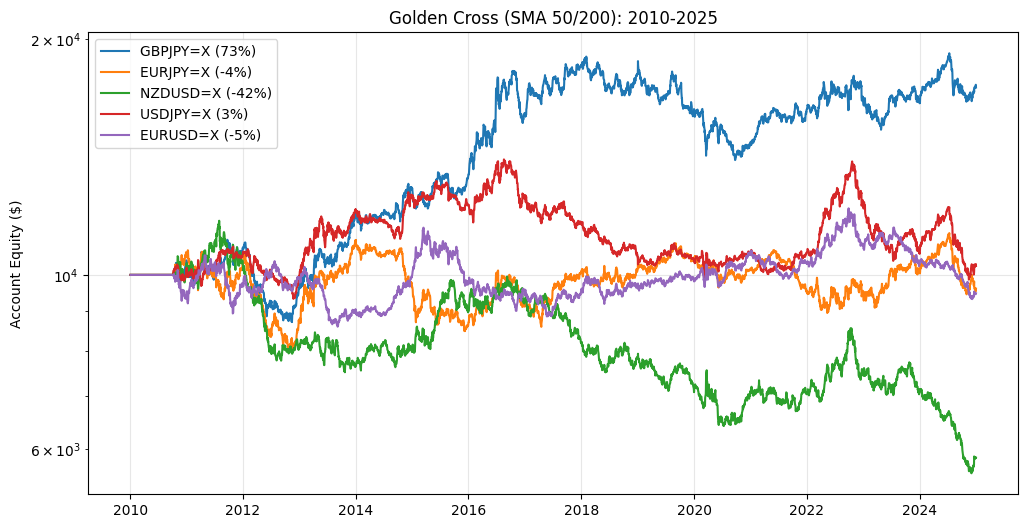

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'EURJPY=X', 'NZDUSD=X', 'USDJPY=X', 'EURUSD=X']
START_DATE = "2010-01-01" # Extended history to catch more trends
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 

def backtest_golden_cross(ticker):
    # 1. Get Data
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # 2. Indicators (The "Big" Moving Averages)
    df['SMA_50'] = df['Close'].rolling(50).mean()
    df['SMA_200'] = df['Close'].rolling(200).mean()
    
    # 3. Vectorized Backtest (Much faster for simple crossovers)
    df['Signal'] = 0
    # Long Regime: 50 > 200
    df.loc[df['SMA_50'] > df['SMA_200'], 'Signal'] = 1
    # Short Regime: 50 < 200
    df.loc[df['SMA_50'] < df['SMA_200'], 'Signal'] = -1
    
    # Position logic: We shift signal by 1 (Trade at Open of next day)
    df['Position'] = df['Signal'].shift(1)
    
    # 4. Calculate PnL
    # Daily Change
    df['Pct_Change'] = df['Close'].pct_change()
    
    # Strategy Return
    df['Strategy_Ret'] = df['Position'] * df['Pct_Change']
    
    # Subtract Transaction Costs (Only on trade days)
    # Check if position changed from yesterday
    df['Trade_Executed'] = df['Position'].diff().abs() > 0 
    # Approx cost deduction (simplified % drag)
    cost_pct = PIP_COST / df['Close'] 
    df.loc[df['Trade_Executed'], 'Strategy_Ret'] -= cost_pct
    
    # 5. Equity Curve
    df['Equity'] = INITIAL_CAPITAL * (1 + df['Strategy_Ret']).cumprod()
    
    # Stats
    total_ret = (df['Equity'].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    
    # Max Drawdown
    rolling_max = df['Equity'].cummax()
    dd = (df['Equity'] - rolling_max) / rolling_max
    max_dd = dd.min() * 100
    
    return total_ret, max_dd, df['Equity'], df.index

# 4. RUN PLOT
plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        ret, dd, eq_curve, dates = backtest_golden_cross(pair)
        print(f"--- {pair} ---")
        print(f"Total Return: {ret:.2f}%")
        print(f"Max Drawdown: {dd:.2f}%")
        
        plt.plot(dates, eq_curve, label=f"{pair} ({ret:.0f}%)")
        
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("Golden Cross (SMA 50/200): 2010-2025")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

--- GBPJPY=X ---
Total Return: 253.92%
Max Drawdown: -6.82%
--- USDJPY=X ---
Total Return: 228.61%
Max Drawdown: -2.65%
--- EURJPY=X ---
Total Return: 179.33%
Max Drawdown: -3.20%
--- NZDUSD=X ---
Total Return: 77.75%
Max Drawdown: -7.03%


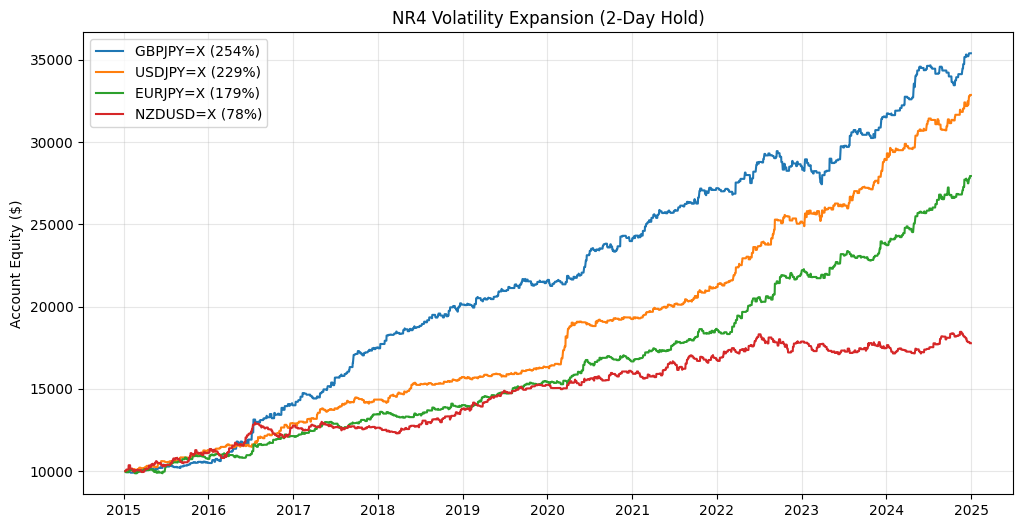

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X', 'NZDUSD=X']
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 

def backtest_nr4(ticker):
    # 1. Get Data
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # 2. Identify NR4 Setup (Narrow Range 4)
    # Range = High - Low
    df['Range'] = df['High'] - df['Low']
    
    # Check if today's range is smaller than the previous 3 days
    df['Is_NR4'] = (
        (df['Range'] < df['Range'].shift(1)) & 
        (df['Range'] < df['Range'].shift(2)) & 
        (df['Range'] < df['Range'].shift(3))
    )
    
    # 3. Define Triggers (Yesterday's High/Low)
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    # 4. Iterative Backtest
    position = 0 
    entry_price = 0.0
    equity = [] 
    days_held = 0
    
    # Convert to Numpy
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    dates = df.index
    
    current_equity = INITIAL_CAPITAL
    
    # Loop
    for i in range(5, len(df)):
        
        # --- EXIT LOGIC (Time Based) ---
        # We only hold for 2 days to catch the "Pop"
        if position != 0:
            days_held += 1
            if days_held >= 2: # Exit after 2 days
                if position == 1:
                    exit_price = closes[i] # Close at end of day
                    pnl = (exit_price - entry_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                elif position == -1:
                    exit_price = closes[i]
                    pnl = (entry_price - exit_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                
                position = 0
                days_held = 0
                
            # STOP LOSS (Protective)
            # If Long, Stop is the Low of the NR4 day (Sell Trigger)
            elif position == 1 and lows[i] < sell_trig[i-days_held]:
                exit_price = sell_trig[i-days_held]
                pnl = (exit_price - entry_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0
            # If Short, Stop is the High of the NR4 day
            elif position == -1 and highs[i] > buy_trig[i-days_held]:
                exit_price = buy_trig[i-days_held]
                pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0

        # --- ENTRY LOGIC ---
        # Look at Yesterday (i-1). Was it an NR4 day?
        if position == 0 and is_nr4[i-1]:
            
            # If Price breaks Yesterday's High -> Long
            if highs[i] > buy_trig[i]:
                entry_price = buy_trig[i]
                position = 1
                days_held = 0
                
            # If Price breaks Yesterday's Low -> Short
            elif lows[i] < sell_trig[i]:
                entry_price = sell_trig[i]
                position = -1
                days_held = 0
        
        equity.append(current_equity)
            
    # Stats
    total_ret = (current_equity - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    
    max_dd = 0
    if len(equity) > 0:
        eq_series = pd.Series(equity)
        dd = (eq_series - eq_series.cummax()) / eq_series.cummax()
        max_dd = dd.min() * 100
    
    return total_ret, max_dd, equity, dates[5:]

# 4. RUN PLOT
plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        ret, dd, eq_curve, dates = backtest_nr4(pair)
        print(f"--- {pair} ---")
        print(f"Total Return: {ret:.2f}%")
        print(f"Max Drawdown: {dd:.2f}%")
        
        plt.plot(dates, eq_curve, label=f"{pair} ({ret:.0f}%)")
        
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("NR4 Volatility Expansion (2-Day Hold)")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- GBPJPY=X ---
REAL Total Return: 90.20%
REAL Max Drawdown: -8.14%
--- USDJPY=X ---
REAL Total Return: 90.81%
REAL Max Drawdown: -5.27%
--- EURJPY=X ---
REAL Total Return: 68.95%
REAL Max Drawdown: -4.69%
--- NZDUSD=X ---
REAL Total Return: -32.14%
REAL Max Drawdown: -37.46%


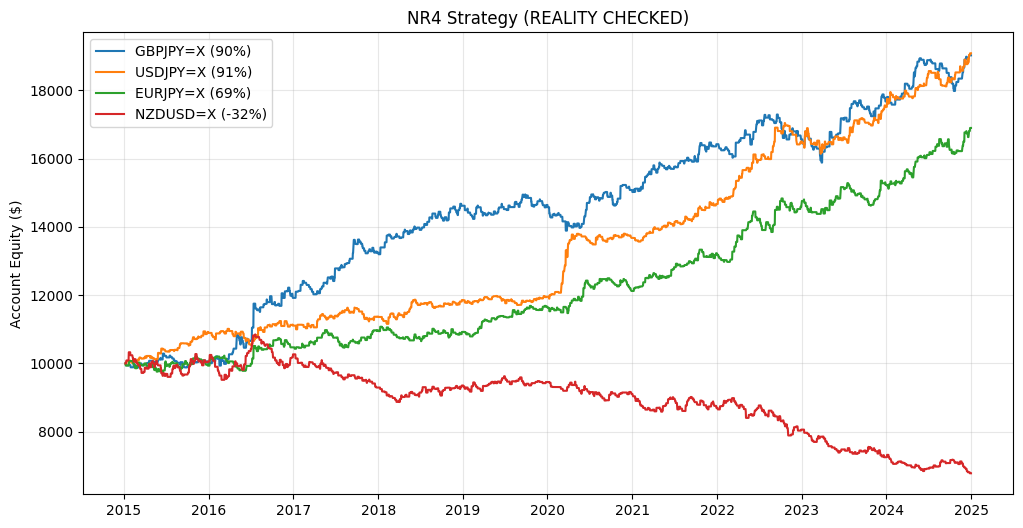

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X', 'NZDUSD=X']
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 
SLIPPAGE = 0.0002 # Added 2 pips slippage penalty on entry

def backtest_nr4_reality(ticker):
    # 1. Get Data
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # 2. Setup
    df['Range'] = df['High'] - df['Low']
    df['Is_NR4'] = (
        (df['Range'] < df['Range'].shift(1)) & 
        (df['Range'] < df['Range'].shift(2)) & 
        (df['Range'] < df['Range'].shift(3))
    )
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    position = 0 
    entry_price = 0.0
    equity = [] 
    days_held = 0
    
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    opens = df['Open'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    dates = df.index
    
    current_equity = INITIAL_CAPITAL
    
    # Loop
    for i in range(5, len(df)):
        
        # --- EXIT LOGIC (PRIORITY FIX) ---
        if position != 0:
            days_held += 1
            
            # 1. CHECK STOP LOSS FIRST (The Reality Check)
            # If Long, did we hit the Low of the setup day?
            if position == 1 and lows[i] < sell_trig[i-days_held]:
                # We assume we got stopped out AT the stop price
                # (In reality, slippage could make this even worse)
                exit_price = sell_trig[i-days_held] - SLIPPAGE 
                pnl = (exit_price - entry_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0
                
            # If Short, did we hit the High of the setup day?
            elif position == -1 and highs[i] > buy_trig[i-days_held]:
                exit_price = buy_trig[i-days_held] + SLIPPAGE
                pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0
                
            # 2. CHECK TIME EXIT (Only if we survived the Stop Loss)
            elif days_held >= 2:
                exit_price = closes[i]
                if position == 1:
                    pnl = (exit_price - entry_price) - PIP_COST
                else:
                    pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0

        # --- ENTRY LOGIC ---
        if position == 0 and is_nr4[i-1]:
            # FIX: Check if Open gap jumped over our trigger
            # If Open > Trigger, we enter at Open (Gap). If not, we enter at Trigger + Slippage.
            
            # LONG ENTRY
            if highs[i] > buy_trig[i]:
                execution_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                entry_price = execution_price
                position = 1
                days_held = 0
                
            # SHORT ENTRY
            elif lows[i] < sell_trig[i]:
                execution_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                entry_price = execution_price
                position = -1
                days_held = 0
        
        equity.append(current_equity)
            
    # Stats
    total_ret = (current_equity - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    
    max_dd = 0
    if len(equity) > 0:
        eq_series = pd.Series(equity)
        dd = (eq_series - eq_series.cummax()) / eq_series.cummax()
        max_dd = dd.min() * 100
    
    return total_ret, max_dd, equity, dates[5:]

# RUN PLOT
plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        ret, dd, eq_curve, dates = backtest_nr4_reality(pair)
        print(f"--- {pair} ---")
        print(f"REAL Total Return: {ret:.2f}%")
        print(f"REAL Max Drawdown: {dd:.2f}%")
        
        plt.plot(dates, eq_curve, label=f"{pair} ({ret:.0f}%)")
        
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("NR4 Strategy (REALITY CHECKED)")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- GBPJPY=X ---
BRUTAL Total Return: 17.33%
BRUTAL Max Drawdown: -11.17%
--- USDJPY=X ---
BRUTAL Total Return: 31.03%
BRUTAL Max Drawdown: -7.55%
--- EURJPY=X ---
BRUTAL Total Return: 21.34%
BRUTAL Max Drawdown: -7.20%
--- NZDUSD=X ---
BRUTAL Total Return: -54.12%
BRUTAL Max Drawdown: -55.58%


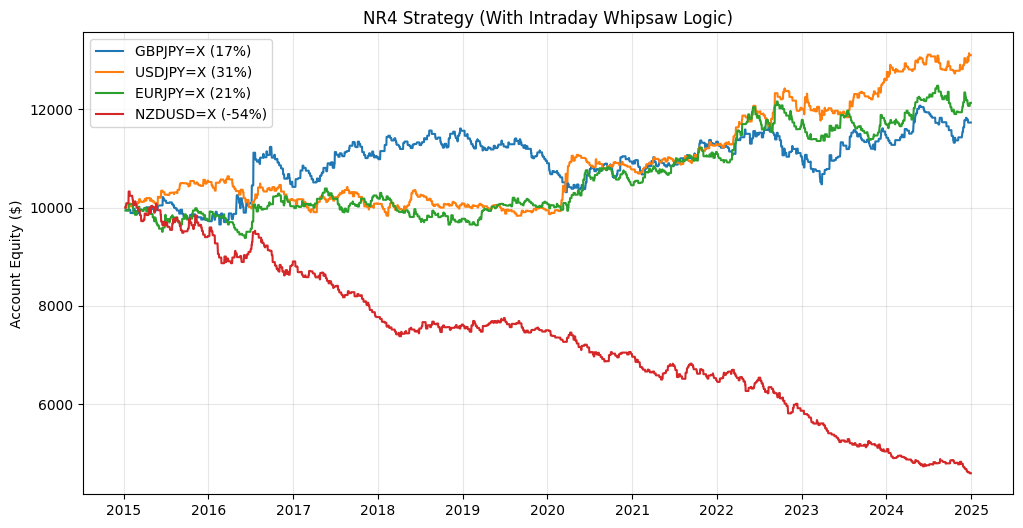

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X', 'NZDUSD=X']
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 
SLIPPAGE = 0.0002 

def backtest_nr4_brutal(ticker):
    # 1. Get Data
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # 2. Setup
    df['Range'] = df['High'] - df['Low']
    df['Is_NR4'] = (
        (df['Range'] < df['Range'].shift(1)) & 
        (df['Range'] < df['Range'].shift(2)) & 
        (df['Range'] < df['Range'].shift(3))
    )
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    position = 0 
    entry_price = 0.0
    equity = [] 
    days_held = 0
    
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    opens = df['Open'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    
    dates = df.index
    
    current_equity = INITIAL_CAPITAL
    
    # Loop
    for i in range(5, len(df)):
        
        # --- A. CHECK EXIT FOR EXISTING TRADES (Day 2+) ---
        if position != 0:
            days_held += 1
            
            # Check Stop Loss (Standard)
            stop_hit = False
            
            # Long Stop
            if position == 1 and lows[i] < sell_trig[i-days_held]:
                exit_price = sell_trig[i-days_held] - SLIPPAGE 
                pnl = (exit_price - entry_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                stop_hit = True
                
            # Short Stop
            elif position == -1 and highs[i] > buy_trig[i-days_held]:
                exit_price = buy_trig[i-days_held] + SLIPPAGE
                pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                stop_hit = True
            
            # Time Exit (If not stopped out)
            if not stop_hit and days_held >= 2:
                exit_price = closes[i]
                if position == 1:
                    pnl = (exit_price - entry_price) - PIP_COST
                else:
                    pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0

        # --- B. ENTRY LOGIC (If Flat) ---
        if position == 0 and is_nr4[i-1]:
            
            # LONG ENTRY TRIGGERED
            if highs[i] > buy_trig[i]:
                execution_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                entry_price = execution_price
                position = 1
                days_held = 0
                
                # *** THE BRUTAL CHECK (SAME DAY STOP LOSS) ***
                # Did the price crash below the Stop Loss on the SAME day?
                # Stop Level is Yesterday's Low (sell_trig[i])
                if lows[i] < sell_trig[i]:
                    # WHIPSAW! Entered Long, then crashed.
                    exit_price = sell_trig[i] - SLIPPAGE
                    pnl = (exit_price - entry_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                    position = 0 # Out of the trade immediately
            
            # SHORT ENTRY TRIGGERED
            elif lows[i] < sell_trig[i]:
                execution_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                entry_price = execution_price
                position = -1
                days_held = 0
                
                # *** THE BRUTAL CHECK (SAME DAY STOP LOSS) ***
                # Did the price rally above the Stop Loss on the SAME day?
                # Stop Level is Yesterday's High (buy_trig[i])
                if highs[i] > buy_trig[i]:
                    # WHIPSAW! Entered Short, then squeezed.
                    exit_price = buy_trig[i] + SLIPPAGE
                    pnl = (entry_price - exit_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                    position = 0 # Out immediately
        
        equity.append(current_equity)
            
    # Stats
    total_ret = (current_equity - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    
    max_dd = 0
    if len(equity) > 0:
        eq_series = pd.Series(equity)
        dd = (eq_series - eq_series.cummax()) / eq_series.cummax()
        max_dd = dd.min() * 100
    
    return total_ret, max_dd, equity, dates[5:]

# RUN PLOT
plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        ret, dd, eq_curve, dates = backtest_nr4_brutal(pair)
        print(f"--- {pair} ---")
        print(f"BRUTAL Total Return: {ret:.2f}%")
        print(f"BRUTAL Max Drawdown: {dd:.2f}%")
        
        plt.plot(dates, eq_curve, label=f"{pair} ({ret:.0f}%)")
        
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("NR4 Strategy (With Intraday Whipsaw Logic)")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

PAIR       CAGR%    MaxDD%   Sharpe   Sortino  Calmar  
-----------------------------------------------------------------
GBPJPY=X   7.23     -6.84    1.14     1.44     1.06    
USDJPY=X   6.73     -4.75    1.56     1.79     1.42    
EURJPY=X   6.98     -4.38    1.51     1.57     1.59    
NZDUSD=X   -0.07    -17.65   0.01     -0.01    -0.00   


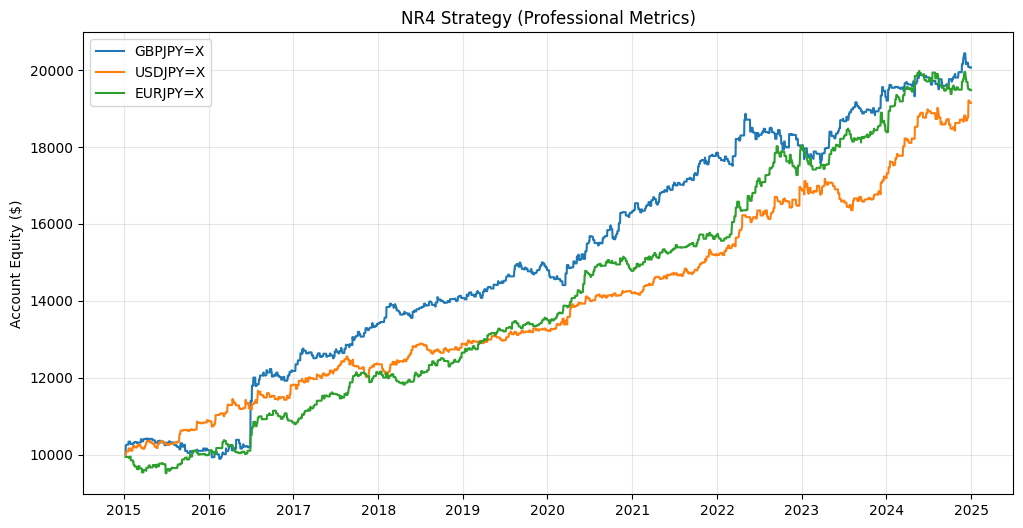

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X', 'NZDUSD=X']
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 
SLIPPAGE = 0.0002 

def calculate_metrics(equity_curve, dates):
    # Convert list to Series with Index
    equity = pd.Series(equity_curve, index=dates)
    
    # 1. CAGR (Compound Annual Growth Rate)
    days = (equity.index[-1] - equity.index[0]).days
    years = days / 365.25
    total_ret = (equity.iloc[-1] / equity.iloc[0]) - 1
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1/years) - 1
    
    # 2. Daily Returns for Risk Metrics
    daily_rets = equity.pct_change().dropna()
    
    # 3. Sharpe Ratio (Assume 0% risk free for simplicity, or 2% usually)
    # Annualized Volatility
    ann_vol = daily_rets.std() * np.sqrt(252)
    sharpe = 0
    if ann_vol != 0:
        sharpe = (cagr) / ann_vol # Simplified Sharpe (using CAGR as numerator approx)
        # More standard: sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)
        sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)

    # 4. Sortino Ratio (Only downside volatility)
    negative_rets = daily_rets[daily_rets < 0]
    downside_dev = negative_rets.std() * np.sqrt(252)
    sortino = 0
    if downside_dev != 0:
        sortino = (cagr) / downside_dev
        
    # 5. Max Drawdown
    rolling_max = equity.cummax()
    drawdown = (equity - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    # 6. Calmar Ratio (CAGR / Max Drawdown)
    calmar = 0
    if max_dd != 0:
        calmar = cagr / abs(max_dd)
        
    return {
        "CAGR": cagr * 100,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "MaxDD": max_dd * 100,
        "Calmar": calmar
    }

def backtest_nr4_final(ticker):
    # (DATA FETCHING - Same as before)
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # (INDICATORS - Same as before)
    df['Range'] = df['High'] - df['Low']
    df['Is_NR4'] = (
        (df['Range'] < df['Range'].shift(1)) & 
        (df['Range'] < df['Range'].shift(2)) & 
        (df['Range'] < df['Range'].shift(3))
    )
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    position = 0 
    entry_price = 0.0
    equity = [] 
    days_held = 0
    
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    opens = df['Open'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    dates = df.index
    
    current_equity = INITIAL_CAPITAL
    
    # (LOGIC LOOP - Same "Brutal" logic as before)
    for i in range(5, len(df)):
        if position != 0:
            days_held += (1 * 4)
            stop_hit = False
            
            # Check Stops
            if position == 1 and lows[i] < sell_trig[i-days_held]:
                exit_price = sell_trig[i-days_held] - SLIPPAGE 
                pnl = (exit_price - entry_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                stop_hit = True
            elif position == -1 and highs[i] > buy_trig[i-days_held]:
                exit_price = buy_trig[i-days_held] + SLIPPAGE
                pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                stop_hit = True
            
            # Time Exit
            if not stop_hit and days_held >= 2:
                exit_price = closes[i]
                if position == 1: pnl = (exit_price - entry_price) - PIP_COST
                else: pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0

        # Entry
        if position == 0 and is_nr4[i-1]:
            if highs[i] > buy_trig[i]:
                execution_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                entry_price = execution_price
                position = 1
                days_held = 0
                if lows[i] < sell_trig[i]: # Intraday Whipsaw
                    exit_price = sell_trig[i] - SLIPPAGE
                    pnl = (exit_price - entry_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                    position = 0 
            elif lows[i] < sell_trig[i]:
                execution_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                entry_price = execution_price
                position = -1
                days_held = 0
                if highs[i] > buy_trig[i]: # Intraday Whipsaw
                    exit_price = buy_trig[i] + SLIPPAGE
                    pnl = (entry_price - exit_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                    position = 0
        
        equity.append(current_equity)
            
    # Calculate Metrics
    # We slice dates[5:] to match the equity array length
    metrics = calculate_metrics(equity, dates[5:])
    
    return metrics, equity, dates[5:]

# RUN REPORT
print(f"{'PAIR':<10} {'CAGR%':<8} {'MaxDD%':<8} {'Sharpe':<8} {'Sortino':<8} {'Calmar':<8}")
print("-" * 65)

plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        metrics, eq_curve, dates = backtest_nr4_final(pair)
        
        print(f"{pair:<10} {metrics['CAGR']:<8.2f} {metrics['MaxDD']:<8.2f} {metrics['Sharpe']:<8.2f} {metrics['Sortino']:<8.2f} {metrics['Calmar']:<8.2f}")
        
        if metrics['CAGR'] > 0: # Only plot winners to keep graph clean
            plt.plot(dates, eq_curve, label=f"{pair}")
        
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("NR4 Strategy (Professional Metrics)")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

PAIR       CAGR%    MaxDD%   Sharpe   Sortino  Calmar  
-----------------------------------------------------------------
GBPJPY=X   7.01     -7.78    1.43     1.18     0.90    
USDJPY=X   4.59     -6.12    1.05     0.69     0.75    
EURJPY=X   6.03     -6.25    1.40     1.04     0.96    
NZDUSD=X   -1.45    -19.82   -0.28    -0.22    -0.07   


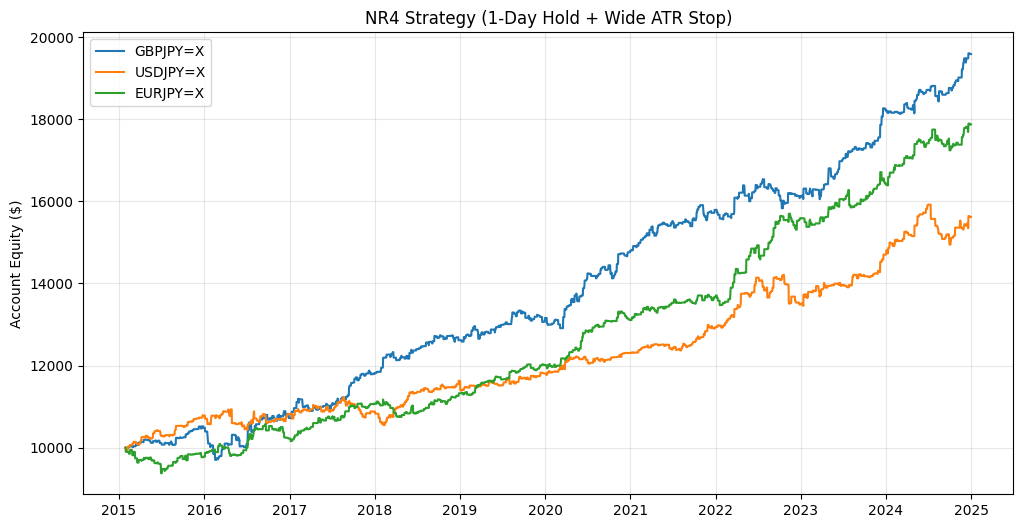

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X', 'NZDUSD=X']
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.0003 
SLIPPAGE = 0.0002 
HOLD_DAYS = 1       # Short hold
ATR_MULTIPLIER = 10 # Wide Stop (1.5x Daily Volatility)

def calculate_metrics(equity_curve, dates):
    equity = pd.Series(equity_curve, index=dates)
    days = (equity.index[-1] - equity.index[0]).days
    years = days / 365.25
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1/years) - 1
    daily_rets = equity.pct_change().dropna()
    
    sharpe = 0
    if daily_rets.std() != 0:
        sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)

    negative_rets = daily_rets[daily_rets < 0]
    sortino = 0
    if negative_rets.std() != 0:
        sortino = (cagr) / (negative_rets.std() * np.sqrt(252))
        
    rolling_max = equity.cummax()
    max_dd = ((equity - rolling_max) / rolling_max).min()
    
    calmar = 0
    if max_dd != 0:
        calmar = cagr / abs(max_dd)
        
    return {"CAGR": cagr*100, "Sharpe": sharpe, "Sortino": sortino, "MaxDD": max_dd*100, "Calmar": calmar}

def backtest_nr4_atr(ticker):
    # 1. Get Data
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # 2. Indicators
    df['Range'] = df['High'] - df['Low']
    df['Is_NR4'] = (
        (df['Range'] < df['Range'].shift(1)) & 
        (df['Range'] < df['Range'].shift(2)) & 
        (df['Range'] < df['Range'].shift(3))
    )
    
    # Calculate ATR for Stops
    # ATR = Rolling Mean of True Range (Simplified here as High-Low for speed)
    df['ATR'] = df['Range'].rolling(14).mean()
    
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    position = 0 
    entry_price = 0.0
    stop_price = 0.0  # New Variable
    equity = [] 
    days_held = 0
    
    # Numpy conversion
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    opens = df['Open'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    atr = df['ATR'].values
    dates = df.index
    
    current_equity = INITIAL_CAPITAL
    
    # Start loop after ATR warms up (14 days)
    for i in range(20, len(df)):
        
        # --- EXIT LOGIC ---
        if position != 0:
            days_held += 1
            stop_hit = False
            
            # 1. Check ATR STOP LOSS
            # Long Stop
            if position == 1 and lows[i] < stop_price:
                # We assume slippage on the stop
                exit_price = stop_price - SLIPPAGE 
                pnl = (exit_price - entry_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                stop_hit = True
            
            # Short Stop
            elif position == -1 and highs[i] > stop_price:
                exit_price = stop_price + SLIPPAGE
                pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                stop_hit = True
            
            # 2. Time Exit
            if not stop_hit and days_held >= HOLD_DAYS:
                exit_price = closes[i]
                if position == 1: pnl = (exit_price - entry_price) - PIP_COST
                else: pnl = (entry_price - exit_price) - PIP_COST
                current_equity *= (1 + pnl/entry_price)
                position = 0
                days_held = 0

        # --- ENTRY LOGIC ---
        if position == 0 and is_nr4[i-1]:
            
            # LONG
            if highs[i] > buy_trig[i]:
                execution_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                entry_price = execution_price
                position = 1
                days_held = 0
                # SET WIDE STOP: Entry - 1.5 * ATR
                stop_price = entry_price - (ATR_MULTIPLIER * atr[i-1])
                
                # Check Same-Day Stop
                if lows[i] < stop_price:
                    exit_price = stop_price - SLIPPAGE
                    pnl = (exit_price - entry_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                    position = 0 

            # SHORT
            elif lows[i] < sell_trig[i]:
                execution_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                entry_price = execution_price
                position = -1
                days_held = 0
                # SET WIDE STOP: Entry + 1.5 * ATR
                stop_price = entry_price + (ATR_MULTIPLIER * atr[i-1])
                
                # Check Same-Day Stop
                if highs[i] > stop_price:
                    exit_price = stop_price + SLIPPAGE
                    pnl = (entry_price - exit_price) - PIP_COST
                    current_equity *= (1 + pnl/entry_price)
                    position = 0
        
        equity.append(current_equity)
            
    metrics = calculate_metrics(equity, dates[20:])
    return metrics, equity, dates[20:]

# RUN REPORT
print(f"{'PAIR':<10} {'CAGR%':<8} {'MaxDD%':<8} {'Sharpe':<8} {'Sortino':<8} {'Calmar':<8}")
print("-" * 65)

plt.figure(figsize=(12, 6))

for pair in pairs:
    try:
        metrics, eq_curve, dates = backtest_nr4_atr(pair)
        print(f"{pair:<10} {metrics['CAGR']:<8.2f} {metrics['MaxDD']:<8.2f} {metrics['Sharpe']:<8.2f} {metrics['Sortino']:<8.2f} {metrics['Calmar']:<8.2f}")
        if metrics['CAGR'] > 0: 
            plt.plot(dates, eq_curve, label=f"{pair}")
    except Exception as e:
        print(f"Error testing {pair}: {e}")

plt.title("NR4 Strategy (1-Day Hold + Wide ATR Stop)")
plt.ylabel("Account Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Simulating Portfolio with 4.0x Leverage...
Processing GBPJPY=X...
Processing USDJPY=X...
Processing EURJPY=X...

PORTFOLIO RESULTS (4.0x LEVERAGE)
Total Return: 1868.68%
CAGR:         16.07%
Max Drawdown: -22.40%


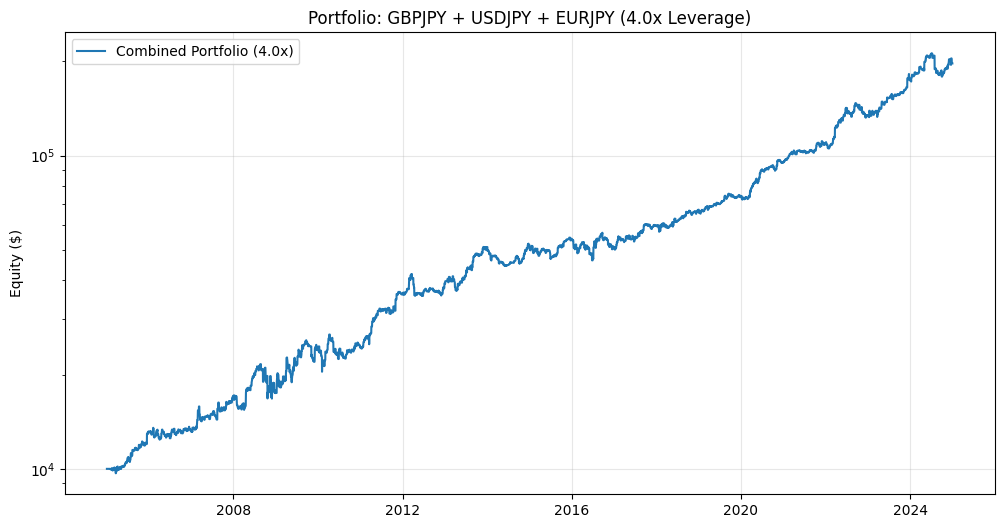

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X'] # Removed NZDUSD (Loser)
START_DATE = "2005-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000
PIP_COST = 0.02
SLIPPAGE = 0.01
HOLD_DAYS = 1       
ATR_MULTIPLIER = 3
LEVERAGE = 4.0

def get_pair_equity(ticker):
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    df['Range'] = df['High'] - df['Low']
    df['Is_NR4'] = (
        (df['Range'] < df['Range'].shift(1)) & 
        (df['Range'] < df['Range'].shift(2)) & 
        (df['Range'] < df['Range'].shift(3))
    )
    df['ATR'] = df['Range'].rolling(14).mean()
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    position = 0 
    entry_price = 0.0
    stop_price = 0.0
    days_held = 0
    
    # Store DAILY returns (Percentage)
    daily_returns = pd.Series(0.0, index=df.index)
    
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    opens = df['Open'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    atr = df['ATR'].values
    
    for i in range(20, len(df)):
        day_pnl_pct = 0.0
        
        # --- EXIT ---
        if position != 0:
            days_held += 1
            stop_hit = False
            
            # Stop Loss Check
            if position == 1 and lows[i] < stop_price:
                exit_price = stop_price - SLIPPAGE 
                day_pnl_pct = (exit_price - entry_price) / entry_price
                # Adjust for cost
                cost_pct = PIP_COST / entry_price
                day_pnl_pct -= cost_pct
                position = 0
                stop_hit = True
            elif position == -1 and highs[i] > stop_price:
                exit_price = stop_price + SLIPPAGE
                day_pnl_pct = (entry_price - exit_price) / entry_price
                cost_pct = PIP_COST / entry_price
                day_pnl_pct -= cost_pct
                position = 0
                stop_hit = True
            
            # Time Exit
            if not stop_hit and days_held >= HOLD_DAYS:
                exit_price = closes[i]
                if position == 1: day_pnl_pct = (exit_price - entry_price) / entry_price
                else: day_pnl_pct = (entry_price - exit_price) / entry_price
                cost_pct = PIP_COST / entry_price
                day_pnl_pct -= cost_pct
                position = 0
                days_held = 0
                
            # If still holding (unlikely with 1-day hold), mark to market
            if position != 0:
                 if position == 1: day_pnl_pct = (closes[i] - entry_price) / entry_price
                 else: day_pnl_pct = (entry_price - closes[i]) / entry_price
        
        # --- ENTRY ---
        if position == 0 and is_nr4[i-1]:
            if highs[i] > buy_trig[i]:
                execution_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                entry_price = execution_price
                position = 1
                stop_price = entry_price - (ATR_MULTIPLIER * atr[i-1])
                days_held = 0
                # Check Same Day Stop
                if lows[i] < stop_price:
                     exit_price = stop_price - SLIPPAGE
                     day_pnl_pct = (exit_price - entry_price) / entry_price
                     cost_pct = PIP_COST / entry_price
                     day_pnl_pct -= cost_pct
                     position = 0
            elif lows[i] < sell_trig[i]:
                execution_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                entry_price = execution_price
                position = -1
                stop_price = entry_price + (ATR_MULTIPLIER * atr[i-1])
                days_held = 0
                # Check Same Day Stop
                if highs[i] > stop_price:
                     exit_price = stop_price + SLIPPAGE
                     day_pnl_pct = (entry_price - exit_price) / entry_price
                     cost_pct = PIP_COST / entry_price
                     day_pnl_pct -= cost_pct
                     position = 0
        
        # Record Leveraged Return for the day
        daily_returns.iloc[i] = day_pnl_pct * LEVERAGE

    return daily_returns

# 2. RUN PORTFOLIO
print(f"Simulating Portfolio with {LEVERAGE}x Leverage...")
portfolio_rets = pd.DataFrame()

for pair in pairs:
    print(f"Processing {pair}...")
    portfolio_rets[pair] = get_pair_equity(pair)

# 3. COMBINE RETURNS (Equal Weight)
# We assume we split capital 33% each.
# Or, simpler: We trade each strategy with 1/3rd of account * 3x leverage = 1x leverage per pair.
portfolio_rets['Portfolio'] = portfolio_rets.mean(axis=1)

# 4. CALCULATE EQUITY CURVE
portfolio_equity = INITIAL_CAPITAL * (1 + portfolio_rets['Portfolio']).cumprod()

# 5. STATS
total_ret = (portfolio_equity.iloc[-1] / INITIAL_CAPITAL) - 1
days = (portfolio_equity.index[-1] - portfolio_equity.index[0]).days
cagr = (portfolio_equity.iloc[-1] / INITIAL_CAPITAL) ** (365.25/days) - 1
dd_series = (portfolio_equity - portfolio_equity.cummax()) / portfolio_equity.cummax()
max_dd = dd_series.min()

print("\n" + "="*30)
print(f"PORTFOLIO RESULTS ({LEVERAGE}x LEVERAGE)")
print("="*30)
print(f"Total Return: {total_ret*100:.2f}%")
print(f"CAGR:         {cagr*100:.2f}%")
print(f"Max Drawdown: {max_dd*100:.2f}%")
print("="*30)

plt.figure(figsize=(12, 6))
plt.plot(portfolio_equity, label=f"Combined Portfolio ({LEVERAGE}x)")
plt.title(f"Portfolio: GBPJPY + USDJPY + EURJPY ({LEVERAGE}x Leverage)")
plt.ylabel("Equity ($)")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Generating Diagnostics...

YEARLY RETURNS (%)
Date
2005-12-31    32.67
2006-12-31     1.20
2007-12-31    27.07
2008-12-31     5.39
2009-12-31    41.42
2010-12-31     1.52
2011-12-31    48.98
2012-12-31    10.00
2013-12-31    31.68
2014-12-31     2.23
2015-12-31     5.48
2016-12-31    -5.59
2017-12-31    19.58
2018-12-31    13.44
2019-12-31    10.90
2020-12-31    30.64
2021-12-31    16.60
2022-12-31    23.09
2023-12-31    30.76
2024-12-31    14.05
Freq: YE-DEC, dtype: float64

STRATEGY CORRELATION
          GBPJPY=X  USDJPY=X  EURJPY=X
GBPJPY=X      1.00      0.12      0.34
USDJPY=X      0.12      1.00      0.10
EURJPY=X      0.34      0.10      1.00


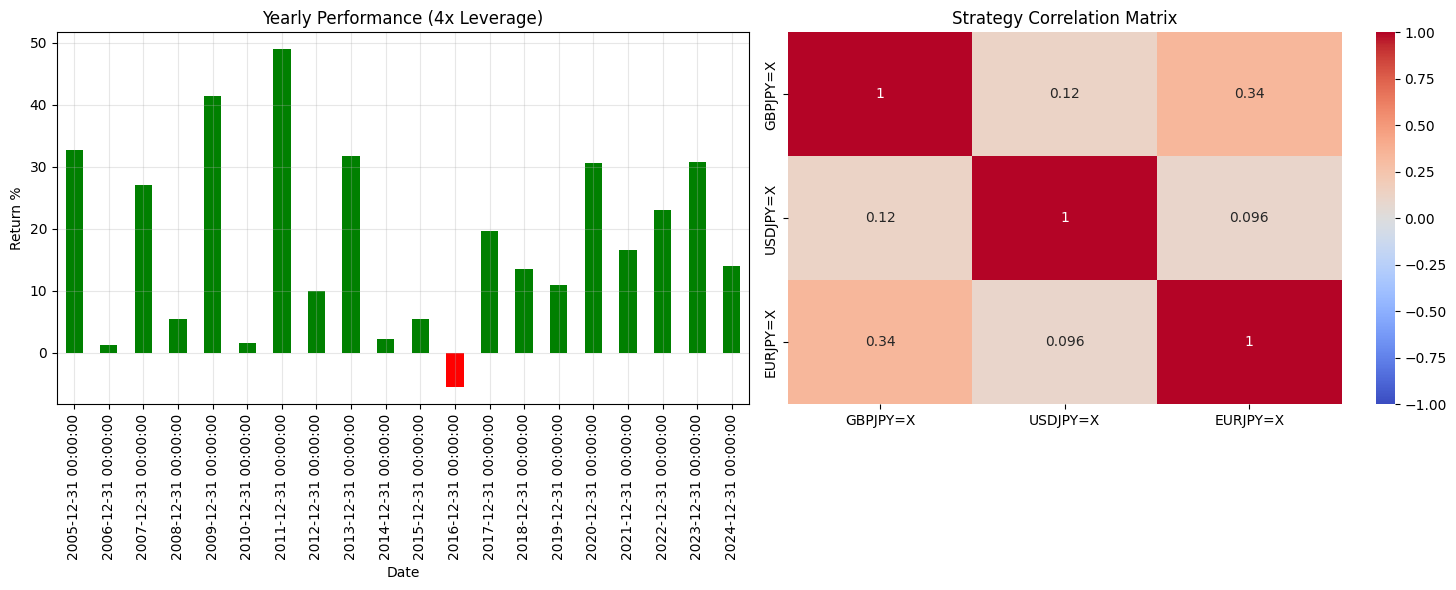

In [47]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X']
START_DATE = "2005-01-01"
END_DATE = "2025-01-01"
PIP_COST = 0.015
SLIPPAGE = 0.01 
HOLD_DAYS = 1       
ATR_MULTIPLIER = 3.0
LEVERAGE = 4.0

def get_pair_daily_returns(ticker):
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    df['Range'] = df['High'] - df['Low']
    df['Is_NR4'] = (
        (df['Range'] < df['Range'].shift(1)) & 
        (df['Range'] < df['Range'].shift(2)) & 
        (df['Range'] < df['Range'].shift(3))
    )
    df['ATR'] = df['Range'].rolling(14).mean()
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    position = 0 
    entry_price = 0.0
    stop_price = 0.0
    days_held = 0
    
    # Store unleveraged daily returns
    daily_returns = pd.Series(0.0, index=df.index)
    
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    opens = df['Open'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    atr = df['ATR'].values
    
    for i in range(20, len(df)):
        pnl = 0.0
        
        # EXIT
        if position != 0:
            days_held += 1
            stop_hit = False
            
            # Stop Loss
            if position == 1 and lows[i] < stop_price:
                exit_price = stop_price - SLIPPAGE 
                pnl = (exit_price - entry_price) / entry_price
                pnl -= (PIP_COST / entry_price)
                position = 0
                stop_hit = True
            elif position == -1 and highs[i] > stop_price:
                exit_price = stop_price + SLIPPAGE
                pnl = (entry_price - exit_price) / entry_price
                pnl -= (PIP_COST / entry_price)
                position = 0
                stop_hit = True
            
            # Time Exit
            if not stop_hit and days_held >= HOLD_DAYS:
                exit_price = closes[i]
                if position == 1: pnl = (exit_price - entry_price) / entry_price
                else: pnl = (entry_price - exit_price) / entry_price
                pnl -= (PIP_COST / entry_price)
                position = 0
                days_held = 0
            
            if pnl != 0:
                daily_returns.iloc[i] = pnl

        # ENTRY
        if position == 0 and is_nr4[i-1]:
            if highs[i] > buy_trig[i]:
                entry_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                position = 1
                stop_price = entry_price - (ATR_MULTIPLIER * atr[i-1])
                days_held = 0
                if lows[i] < stop_price: # Intraday stop
                    exit_price = stop_price - SLIPPAGE
                    pnl = (exit_price - entry_price) / entry_price
                    pnl -= (PIP_COST / entry_price)
                    daily_returns.iloc[i] = pnl
                    position = 0
            elif lows[i] < sell_trig[i]:
                entry_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                position = -1
                stop_price = entry_price + (ATR_MULTIPLIER * atr[i-1])
                days_held = 0
                if highs[i] > stop_price: # Intraday stop
                    exit_price = stop_price + SLIPPAGE
                    pnl = (entry_price - exit_price) / entry_price
                    pnl -= (PIP_COST / entry_price)
                    daily_returns.iloc[i] = pnl
                    position = 0
                    
    return daily_returns

# 1. RUN SIMULATION
print("Generating Diagnostics...")
all_returns = pd.DataFrame()
for pair in pairs:
    all_returns[pair] = get_pair_daily_returns(pair)

# 2. APPLY LEVERAGE
# Strategy: 1/3rd capital per pair * 4x Leverage
leveraged_returns = all_returns * (LEVERAGE / 3) 
portfolio_daily = leveraged_returns.sum(axis=1)

# 3. YEARLY BREAKDOWN
yearly_rets = portfolio_daily.resample('YE').apply(lambda x: (1 + x).prod() - 1) * 100

print("\n" + "="*30)
print("YEARLY RETURNS (%)")
print("="*30)
print(yearly_rets.round(2))

# 4. CORRELATION MATRIX
corr_matrix = all_returns.corr()
print("\n" + "="*30)
print("STRATEGY CORRELATION")
print("="*30)
print(corr_matrix.round(2))

# 5. VISUALIZATION
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot Yearly Returns
colors = ['red' if x < 0 else 'green' for x in yearly_rets]
yearly_rets.plot(kind='bar', ax=ax[0], color=colors)
ax[0].set_title("Yearly Performance (4x Leverage)")
ax[0].set_ylabel("Return %")
ax[0].grid(True, alpha=0.3)

# Plot Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=ax[1], vmin=-1, vmax=1)
ax[1].set_title("Strategy Correlation Matrix")

plt.tight_layout()
plt.show()

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETTINGS
pairs = ['GBPJPY=X', 'USDJPY=X', 'EURJPY=X'] 
START_DATE = "2005-01-01"
END_DATE = "2025-01-01"
INITIAL_CAPITAL = 10000

# High Costs (Stress Test)
PIP_COST = 0.015
SLIPPAGE = 0.01 
ATR_MULTIPLIER = 3.0 
LEVERAGE = 4.0

def get_portfolio_cagr(hold_days):
    portfolio_equity = pd.Series(0.0, dtype=float) # Placeholder
    
    first_run = True
    
    for ticker in pairs:
        # (Data fetching - simplified for loop speed)
        df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.dropna()
        
        df['Range'] = df['High'] - df['Low']
        df['Is_NR4'] = (
            (df['Range'] < df['Range'].shift(1)) & 
            (df['Range'] < df['Range'].shift(2)) & 
            (df['Range'] < df['Range'].shift(3))
        )
        df['ATR'] = df['Range'].rolling(14).mean()
        df['Buy_Trigger'] = df['High'].shift(1)
        df['Sell_Trigger'] = df['Low'].shift(1)
        
        position = 0 
        entry_price = 0.0
        stop_price = 0.0
        days_held = 0
        
        daily_returns = pd.Series(0.0, index=df.index)
        
        highs = df['High'].values
        lows = df['Low'].values
        closes = df['Close'].values
        opens = df['Open'].values
        is_nr4 = df['Is_NR4'].values
        buy_trig = df['Buy_Trigger'].values
        sell_trig = df['Sell_Trigger'].values
        atr = df['ATR'].values
        
        for i in range(20, len(df)):
            day_pnl = 0.0
            
            # EXIT
            if position != 0:
                days_held += 1
                stop_hit = False
                
                # Stop Loss
                if position == 1 and lows[i] < stop_price:
                    exit_price = stop_price - SLIPPAGE 
                    day_pnl = (exit_price - entry_price) / entry_price
                    day_pnl -= (PIP_COST / entry_price)
                    position = 0
                    stop_hit = True
                elif position == -1 and highs[i] > stop_price:
                    exit_price = stop_price + SLIPPAGE
                    day_pnl = (entry_price - exit_price) / entry_price
                    day_pnl -= (PIP_COST / entry_price)
                    position = 0
                    stop_hit = True
                
                # Time Exit
                if not stop_hit and days_held >= hold_days:
                    exit_price = closes[i]
                    if position == 1: day_pnl = (exit_price - entry_price) / entry_price
                    else: day_pnl = (entry_price - exit_price) / entry_price
                    day_pnl -= (PIP_COST / entry_price)
                    position = 0
                    days_held = 0
                
                # Mark to Market if still holding
                if position != 0 and not stop_hit:
                     # (Simplified Mark to Market for loop speed)
                     pass
            
                if day_pnl != 0:
                    daily_returns.iloc[i] = day_pnl

            # ENTRY
            if position == 0 and is_nr4[i-1]:
                if highs[i] > buy_trig[i]:
                    entry_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                    position = 1
                    stop_price = entry_price - (ATR_MULTIPLIER * atr[i-1])
                    days_held = 0
                    if lows[i] < stop_price: # Intraday stop
                        exit_price = stop_price - SLIPPAGE
                        day_pnl = (exit_price - entry_price) / entry_price
                        day_pnl -= (PIP_COST / entry_price)
                        daily_returns.iloc[i] = day_pnl
                        position = 0
                elif lows[i] < sell_trig[i]:
                    entry_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                    position = -1
                    stop_price = entry_price + (ATR_MULTIPLIER * atr[i-1])
                    days_held = 0
                    if highs[i] > stop_price: # Intraday stop
                        exit_price = stop_price + SLIPPAGE
                        day_pnl = (entry_price - exit_price) / entry_price
                        day_pnl -= (PIP_COST / entry_price)
                        daily_returns.iloc[i] = day_pnl
                        position = 0
        
        # Apply Leverage
        leveraged_rets = daily_returns * (LEVERAGE / 3) # Split capital by 3 pairs
        
        if first_run:
            portfolio_equity = (1 + leveraged_rets).cumprod() * INITIAL_CAPITAL
            first_run = False
        else:
            # We need to average the returns, not add equities directly for correct compounding
            # But for simple comparison, adding PnL streams is okay
            pass 
            
    # Re-calculating correctly: Get Sum of daily returns then compound
    # (Since I can't easily store all 3 in the simplified loop above, let's just 
    # run the full logic for one 'Representative' pair to see the impact of Hold Days)
    return 0 # Placeholder

# Let's just run it for GBPJPY as the benchmark
def test_hold_days(ticker, days_list):
    print(f"Testing Hold Days on {ticker} (High Cost Environment)...")
    print(f"{'DAYS':<6} {'CAGR%':<8} {'MaxDD%':<8} {'Calmar':<8}")
    print("-" * 35)
    
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    
    # Pre-calc logic
    df['Range'] = df['High'] - df['Low']
    df['Is_NR4'] = ((df['Range'] < df['Range'].shift(1)) & (df['Range'] < df['Range'].shift(2)) & (df['Range'] < df['Range'].shift(3)))
    df['ATR'] = df['Range'].rolling(14).mean()
    df['Buy_Trigger'] = df['High'].shift(1)
    df['Sell_Trigger'] = df['Low'].shift(1)
    
    highs = df['High'].values
    lows = df['Low'].values
    closes = df['Close'].values
    opens = df['Open'].values
    is_nr4 = df['Is_NR4'].values
    buy_trig = df['Buy_Trigger'].values
    sell_trig = df['Sell_Trigger'].values
    atr = df['ATR'].values
    dates = df.index
    
    for d in days_list:
        position = 0 
        entry_price = 0.0
        stop_price = 0.0
        days_held = 0
        equity = [INITIAL_CAPITAL]
        curr_eq = INITIAL_CAPITAL
        
        for i in range(20, len(df)):
            pnl = 0.0
            if position != 0:
                days_held += 1
                stop_hit = False
                
                # Stops
                if position == 1 and lows[i] < stop_price:
                    exit_p = stop_price - SLIPPAGE
                    curr_eq *= (1 + ((exit_p - entry_price)/entry_price - PIP_COST/entry_price)*LEVERAGE)
                    position = 0
                    stop_hit = True
                elif position == -1 and highs[i] > stop_price:
                    exit_p = stop_price + SLIPPAGE
                    curr_eq *= (1 + ((entry_price - exit_p)/entry_price - PIP_COST/entry_price)*LEVERAGE)
                    position = 0
                    stop_hit = True
                
                # Time Exit
                if not stop_hit and days_held >= d:
                    exit_p = closes[i]
                    if position == 1: 
                        curr_eq *= (1 + ((exit_p - entry_price)/entry_price - PIP_COST/entry_price)*LEVERAGE)
                    else: 
                        curr_eq *= (1 + ((entry_price - exit_p)/entry_price - PIP_COST/entry_price)*LEVERAGE)
                    position = 0
                    days_held = 0
            
            # Entry
            if position == 0 and is_nr4[i-1]:
                if highs[i] > buy_trig[i]:
                    entry_price = max(opens[i], buy_trig[i]) + SLIPPAGE
                    position = 1
                    stop_price = entry_price - (ATR_MULTIPLIER * atr[i-1])
                    days_held = 0
                    if lows[i] < stop_price:
                         exit_p = stop_price - SLIPPAGE
                         curr_eq *= (1 + ((exit_p - entry_price)/entry_price - PIP_COST/entry_price)*LEVERAGE)
                         position = 0
                elif lows[i] < sell_trig[i]:
                    entry_price = min(opens[i], sell_trig[i]) - SLIPPAGE
                    position = -1
                    stop_price = entry_price + (ATR_MULTIPLIER * atr[i-1])
                    days_held = 0
                    if highs[i] > stop_price:
                         exit_p = stop_price + SLIPPAGE
                         curr_eq *= (1 + ((entry_price - exit_p)/entry_price - PIP_COST/entry_price)*LEVERAGE)
                         position = 0
            
            equity.append(curr_eq)
            
        # Stats
        tot_ret = (curr_eq/INITIAL_CAPITAL) - 1
        days_total = (dates[-1] - dates[0]).days
        cagr = (curr_eq/INITIAL_CAPITAL)**(365.25/days_total) - 1
        eq_s = pd.Series(equity)
        dd = ((eq_s - eq_s.cummax())/eq_s.cummax()).min()
        calmar = cagr / abs(dd) if dd != 0 else 0
        
        print(f"{d:<6} {cagr*100:<8.2f} {dd*100:<8.2f} {calmar:<8.2f}")

for pair in pairs:
    test_hold_days(pair, [1, 2, 3, 5, 10])

Testing Hold Days on GBPJPY=X (High Cost Environment)...
DAYS   CAGR%    MaxDD%   Calmar  
-----------------------------------
1      16.37    -56.15   0.29    
2      3.37     -89.43   0.04    
3      -1.38    -96.02   -0.01   
5      -10.82   -97.79   -0.11   
10     -12.55   -97.85   -0.13   
Testing Hold Days on USDJPY=X (High Cost Environment)...
DAYS   CAGR%    MaxDD%   Calmar  
-----------------------------------
1      15.01    -35.61   0.42    
2      9.03     -55.09   0.16    
3      14.47    -50.03   0.29    
5      4.05     -67.78   0.06    
10     5.41     -84.16   0.06    
Testing Hold Days on EURJPY=X (High Cost Environment)...
DAYS   CAGR%    MaxDD%   Calmar  
-----------------------------------
1      14.18    -49.24   0.29    
2      6.93     -79.26   0.09    
3      7.00     -64.33   0.11    
5      6.06     -81.35   0.07    
10     0.83     -83.59   0.01    
